# Ch4_Q13 (efghij)
<h3>
This question should be answered using the Weekly data set, which
is part of the ISLP package. This data is similar in nature to the
Smarket data from this chapter’s lab, except that it contains 1, 089
weekly returns for 21 years, from the beginning of 1990 to the end of
2010.

In [1]:
from ISLP import load_data
Weekly = load_data('Weekly')
Weekly.head()

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


### (e) Repeat (d) using LDA.

In [16]:
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, accuracy_score
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']
X_test = test[['Lag2']]
y_test = test['Direction']

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['Up', 'Down'])
acc = accuracy_score(y_test, y_pred)

print("\nLDA — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual Up', 'Actual Down'],
                   columns=['Predicted Up', 'Predicted Down']))
print("\nAccuracy:", round(acc, 3))


LDA — Confusion Matrix:
             Predicted Up  Predicted Down
Actual Up              56               5
Actual Down            34               9

Accuracy: 0.625


we use LDA model with lag2 predictor, the confusion matrix shows the model classify most "up" correctly, and classify most actual down as up. The accuracy is 62.5%

### (f) Repeat (d) using QDA.

In [17]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']
X_test = test[['Lag2']]
y_test = test['Direction']


qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred = qda.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['Up', 'Down'])
acc = accuracy_score(y_test, y_pred)

print("QDA — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual Up', 'Actual Down'],
                   columns=['Predicted Up', 'Predicted Down']))
print("\nAccuracy:", round(acc, 3))

QDA — Confusion Matrix:
             Predicted Up  Predicted Down
Actual Up              61               0
Actual Down            43               0

Accuracy: 0.587


the accuracy is 58.7%, compare with LDA, accuracy of QDA is worse than LDA(62.5%), QDA allow a quadratic decision boundary, it should be get a better perform if the classes were non-linearly separable. but we just use one predictor(lag2) in QDA model, so QDA nearly identically to LDA.

### (g) Repeat (d) using KNN with K = 1.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']
X_test = test[['Lag2']]
y_test = test['Direction']

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['Up', 'Down'])
acc = accuracy_score(y_test, y_pred)

print("KNN (K=1) — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual Up', 'Actual Down'],
                   columns=['Predicted Up', 'Predicted Down']))
print("\nAccuracy:", round(acc, 3))

KNN (K=1) — Confusion Matrix:
             Predicted Up  Predicted Down
Actual Up              31              30
Actual Down            22              21

Accuracy: 0.5


KNN model's accuracy is 50%,  it is the worst performance compare with LDA and QDA

### (h) Repeat (d) using naive Bayes.

In [19]:
from sklearn.naive_bayes import GaussianNB

train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] > 2008]

X_train = train[['Lag2']]
y_train = train['Direction']
X_test = test[['Lag2']]
y_test = test['Direction']

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=['Up', 'Down'])
acc = accuracy_score(y_test, y_pred)

print("Naive Bayes — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual Up', 'Actual Down'],
                   columns=['Predicted Up', 'Predicted Down']))
print("\nAccuracy:", round(acc, 3))

Naive Bayes — Confusion Matrix:
             Predicted Up  Predicted Down
Actual Up              61               0
Actual Down            43               0

Accuracy: 0.587


accuracy is 58.7%, higher than KNN, same with QDA but lower than LDA

### (i) Which of these methods appears to provide the best results on this data?

based on above result, we compare the accuracy as model performance

LR: 62.5%

LDA: 62.5%

QDA: 58.7%

KNN: 50%

Naive Bayes: 58.7%

LR and LDA got a best results on this data.

### (j) Experiment with different combinations of predictors, including possible transformations and interactions, for each of the methods. Report the variables, method, and associated confusion matrix that appears to provide the best results on the held out data. Note that you should also experiment with values for K in the KNN classifier.

In [49]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LogisticRegression

train = Weekly[Weekly['Year'] <= 2008].copy()
test = Weekly[Weekly['Year'] > 2008].copy()

y_train = train['Direction']
y_test = test['Direction']

train.loc[:, 'Lag2_sq'] = train['Lag2']**2
test.loc[:, 'Lag2_sq'] = test['Lag2']**2

In [54]:
candidates = {
    'sq_two' : ['Lag2', 'Lag2_sq'],
    'three_var': ['Lag1', 'Lag2', 'Lag2_sq'],
    'volume_var': ['Lag1', 'Lag2', 'Lag2_sq', 'Volume'],
    'all_var' :  ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume'],
    'sq_all_var' : ['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Lag2_sq']
}

In [55]:
def evaluate_model(model, X_train, y_train, X_test, y_test, label):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred, labels=['Up', 'Down'])
    print(f"\nMethod: {label}")
    print(pd.DataFrame(cm,
                       index=['Actual Up', 'Actual Down'],
                       columns=['Predicted Up', 'Predicted Down']))
    print(f"Accuracy: {acc:.3f}")
    return acc

In [58]:
results = []

for name, features in candidates.items():
    X_train = train[features]
    X_test = test[features]

    # Standardize for models sensitive to scale (e.g., KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\n=== Predictors: {name} ===")

    # LDA
    acc_lda = evaluate_model(LinearDiscriminantAnalysis(), X_train, y_train, X_test, y_test, 'LDA')
    results.append(('LDA', name, acc_lda))

    # QDA
    acc_qda = evaluate_model(QuadraticDiscriminantAnalysis(), X_train, y_train, X_test, y_test, 'QDA')
    results.append(('QDA', name, acc_qda))

    # Logistic Regression
    acc_log = evaluate_model(LogisticRegression(max_iter=1000), X_train, y_train, X_test, y_test, 'LR')
    results.append(('Logistic', name, acc_log))

    # Naive Bayes
    acc_nb = evaluate_model(GaussianNB(), X_train, y_train, X_test, y_test, 'Naive Bayes')
    results.append(('Naive Bayes', name, acc_nb))

    # KNN
    for k in [2, 5, 10]:
        knn = KNeighborsClassifier(n_neighbors=k)
        acc_knn = evaluate_model(knn, X_train_scaled, y_train, X_test_scaled, y_test, f'KNN (k={k})')
        results.append((f'KNN (k={k})', name, acc_knn))



=== Predictors: sq_two ===

Method: LDA
             Predicted Up  Predicted Down
Actual Up              57               4
Actual Down            36               7
Accuracy: 0.615

Method: QDA
             Predicted Up  Predicted Down
Actual Up              58               3
Actual Down            36               7
Accuracy: 0.625

Method: LR
             Predicted Up  Predicted Down
Actual Up              57               4
Actual Down            35               8
Accuracy: 0.625

Method: Naive Bayes
             Predicted Up  Predicted Down
Actual Up              56               5
Actual Down            39               4
Accuracy: 0.577

Method: KNN (k=2)
             Predicted Up  Predicted Down
Actual Up              17              44
Actual Down            12              31
Accuracy: 0.462

Method: KNN (k=5)
             Predicted Up  Predicted Down
Actual Up              40              21
Actual Down            27              16
Accuracy: 0.538

Method: KNN (k=10)
   

In [59]:
df_results = pd.DataFrame(results, columns=['Method', 'Predictors', 'Accuracy'])
best = df_results.sort_values(by='Accuracy', ascending=False).head(5)
print("\nTop 5 models on held-out data (2009–2010):")
print(best)


Top 5 models on held-out data (2009–2010):
        Method Predictors  Accuracy
1          QDA     sq_two  0.625000
2     Logistic     sq_two  0.625000
0          LDA     sq_two  0.615385
8          QDA  three_var  0.596154
3  Naive Bayes     sq_two  0.576923


LR and QDA models use a nonlinear predictor "Lag_sq", reaching a highest accuracy of 62.5%. This result appears to be similar to the LDA & LR model, which only uses "Lag2". The addition of the squared term allowed these models to capture a weak nonlinear mean-reversion pattern. These results indicate that only weak nonlinear dependence exists between past and future weekly returns.

# Ch4_Q14
<h3>In this problem, you will develop a model to predict whether a given
car gets high or low gas mileage based on the Auto data set.

In [72]:
import pandas as pd
import numpy as np
from ISLP import load_data

Auto = load_data('Auto')
Auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


### (a) Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows:
<h3>Auto['mpg01'] = mpg01

In [73]:
# median
mpg_median = Auto['mpg'].median()
print(mpg_median)

22.75


In [ ]:
mpg01 = (Auto['mpg'] > mpg_median).astype(int)
Auto['mpg01'] = mpg01


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


### (b) Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

In [76]:
Auto.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, chevrolet chevelle malibu to chevy s-10
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   mpg01         392 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 30.6+ KB


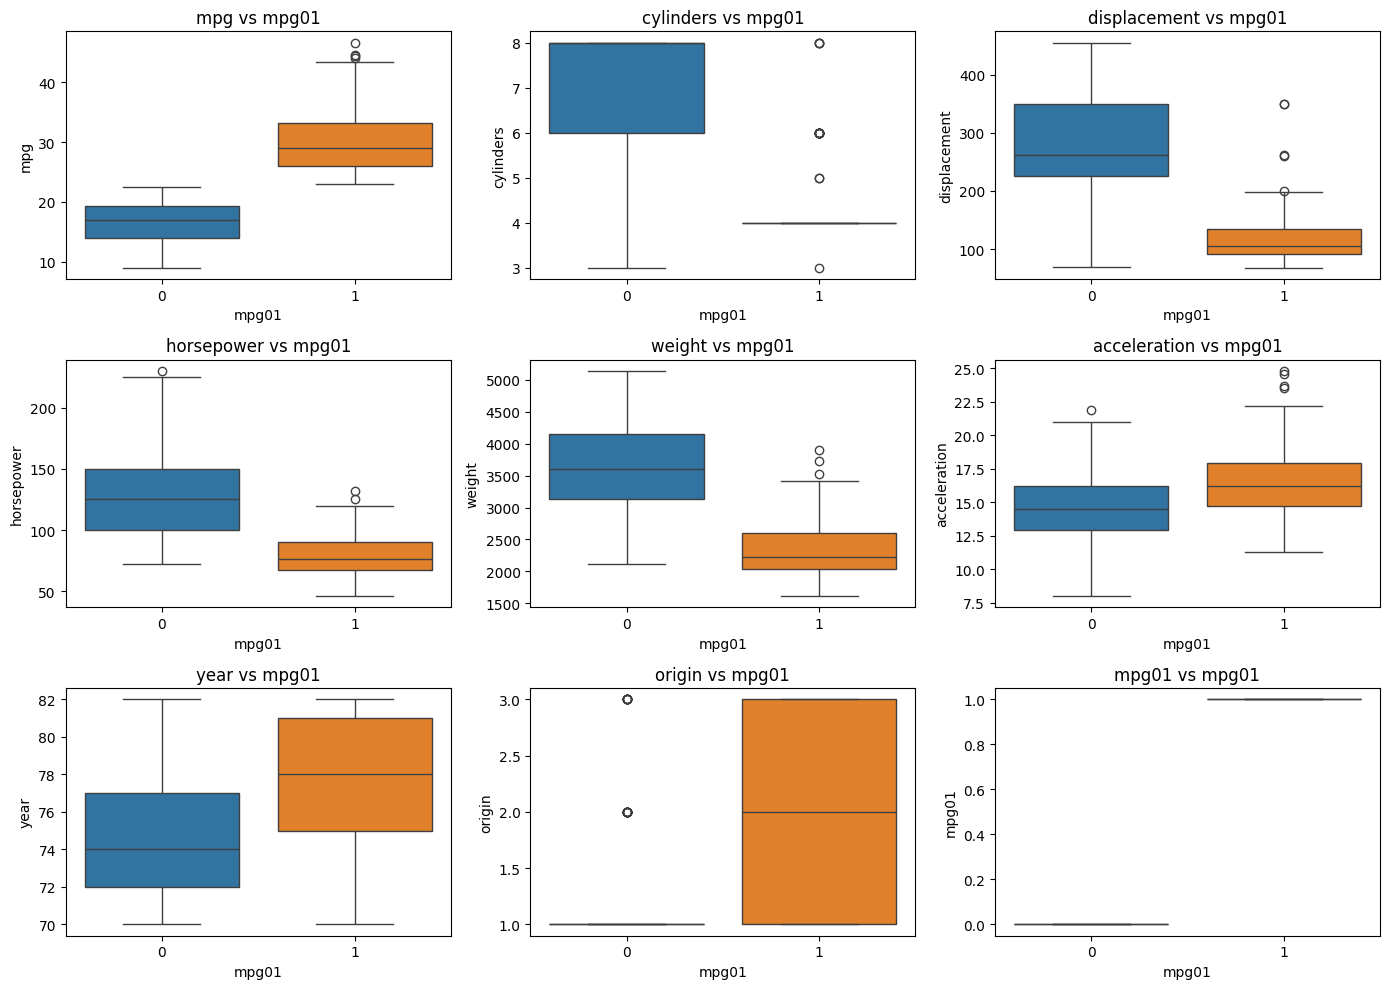

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

features = Auto.columns

plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x='mpg01', y=col, data=Auto,hue='mpg01', legend=False)
    plt.title(f'{col} vs mpg01')
plt.tight_layout()
plt.show()

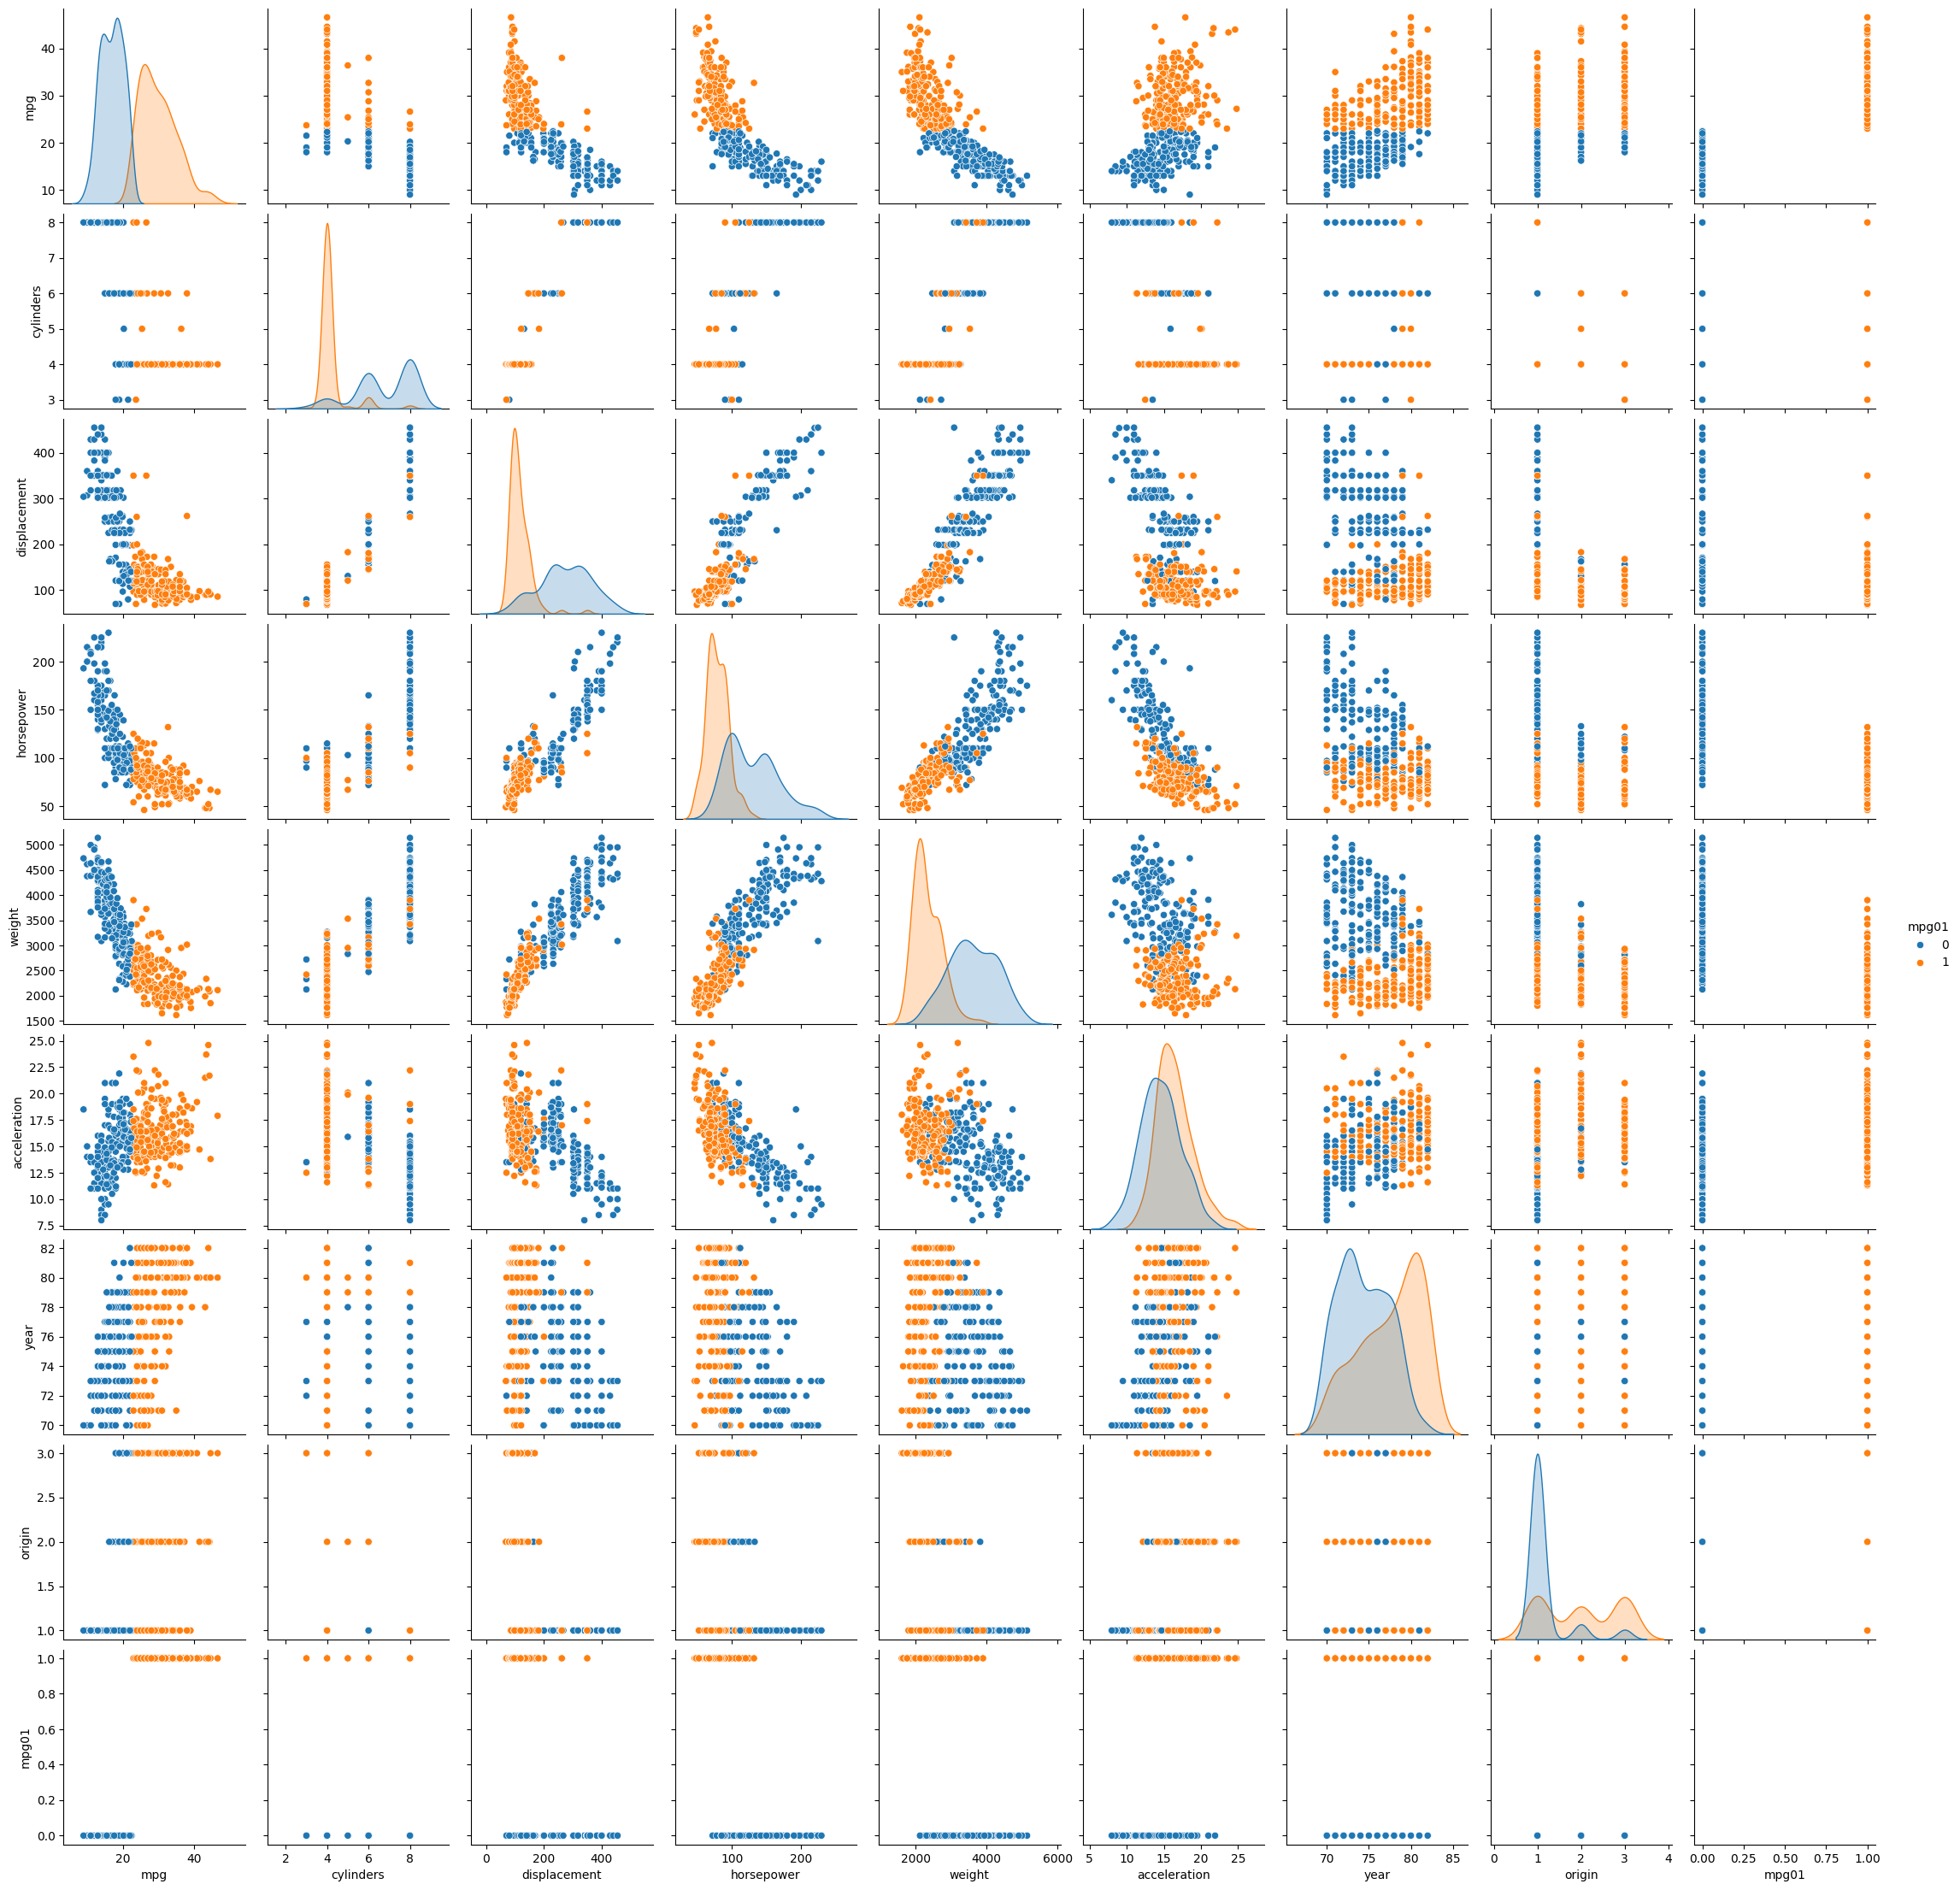

In [84]:
sns.pairplot(Auto, vars=Auto.columns,hue='mpg01',diag_kind='kde')
plt.show()

mpg: The number of miles a car can travel per gallon of fuel, representing fuel efficiency\
cylinders: The number of engine cylinders. More cylinders generally indicate greater engine power but lower fuel efficiency.\
displacement: The total volume of all the engine’s cylinders, measured in cubic inches\
horsepower: The power output of the engine.\
weight: The weight of the car in pounds\
acceleration: The time required for the car to accelerate from 0 to 60 miles per hour, in seconds\
year: The last two digits of the model year\
origin: The region where the car was manufactured: 1 = USA, 2 = Europe, 3 = Asia.

cylinders, displacement, horsepower, and weight show strong negative relationship with mpg01, year and origin show positive relationship with mpg01. we can see the kde plot of variables cylinders, displacement, horsepower and weight, there is a greater separation between the two curves for mpg01=0 and mpg01=1, mpg01=1. Variabe year show mpg01=1 curve skew to right. Variable origin show most of mpg01=0 concentrate on origin = 1, and mpg01=1 evenly distribute to origin=1,2,3. Variable acceleration is not a good predictor because two curve almost overlap

### (c) Split the data into a training set and a test set.

In [85]:
from sklearn.model_selection import train_test_split

X = Auto[['cylinders', 'displacement', 'horsepower', 'weight',
           'acceleration', 'year', 'origin']]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### (d) Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [93]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

y_pred = lda.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc

print("LDA — Confusion Matrix:")
print(pd.DataFrame(cm, 
                   index=['Actual 1', 'Actual 0'],
                   columns=['Predicted 1', 'Predicted 0']))
print(f"\nAccuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

LDA — Confusion Matrix:
          Predicted 1  Predicted 0
Actual 1           52            1
Actual 0            7           58

Accuracy: 0.932
Test Error Rate: 0.068


LDA test accuracy is 93.2% and a corresponding test error rate is 6.8%.

### (e) Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [94]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

y_pred = qda.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc

print("QDA — Confusion Matrix:")
print(pd.DataFrame(cm, 
                   index=['Actual 1', 'Actual 0'],
                   columns=['Predicted 1', 'Predicted 0']))
print(f"\nAccuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

QDA — Confusion Matrix:
          Predicted 1  Predicted 0
Actual 1           49            4
Actual 0            5           60

Accuracy: 0.924
Test Error Rate: 0.076


QDA test accuracy is 92.4% and a corresponding test error rate is 7.6%.  QDA doesnt improve the performance of the model.

### (f) Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [97]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

cm = confusion_matrix(y_test, y_pred, labels=(1,0))
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc

print("Logistic Regression — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual 1', 'Actual 0'],
                   columns=['Predicted 1', 'Predicted 0']))
print(f"\nAccuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

Logistic Regression — Confusion Matrix:
          Predicted 1  Predicted 0
Actual 1           53            0
Actual 0            5           60

Accuracy: 0.958
Test Error Rate: 0.042


LR test accuracy is 95.8% and a corresponding test error rate is 4.2%.  LR improve the performance of the model.

### (g) Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [98]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)

cm = confusion_matrix(y_test, y_pred, labels=[1,0])
acc = accuracy_score(y_test, y_pred)
test_error = 1 - acc

print("Naive Bayes — Confusion Matrix:")
print(pd.DataFrame(cm,
                   index=['Actual 1', 'Actual 0'],
                   columns=['Predicted 1', 'Predicted 0']))
print(f"\nAccuracy: {acc:.3f}")
print(f"Test Error Rate: {test_error:.3f}")

Naive Bayes — Confusion Matrix:
          Predicted 1  Predicted 0
Actual 1           49            4
Actual 0            6           59

Accuracy: 0.915
Test Error Rate: 0.085


Naive Bayes test accuracy is 91.5% and a corresponding test error rate is 8.5%.

### (h) Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

test_errors = []

for k in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    test_errors.append((k, 1 - acc))

results = pd.DataFrame(test_errors, columns=['K', 'Test Error'])
print(results)

    K  Test Error
0   1    0.076271
1   2    0.084746
2   3    0.042373
3   4    0.042373
4   5    0.050847
5   6    0.059322
6   7    0.059322
7   8    0.059322
8   9    0.093220
9  10    0.084746


k=3 get a lowest test errors rate and best performance on this dataset

# Ch4_Q15
<h3>This problem involves writing functions

### (a) Write a function, Power(), that prints out the result of raising 2 to the 3rd power. In other words, your function should compute 2^3 and print out the results.  

Hint: Recall that x**a raises x to the power a. Use the print()function to display the result.

In [ ]:
def Power():
    ans = 2**3
    return ans

Power()

8

### (b) Create a new function, Power2(), that allows you to pass any two numbers, x and a, and prints out the value of x**a. You can do this by beginning your function with the line
<h3> def Power2(x, a):
<h3>You should be able to call your function by entering, for instance, 
<h3>Power2(3, 8)
<h3>on the command line. This should output the value of 3^8, namely,
6, 561.

In [105]:
def Power2(x,a):
    ans = x ** a
    return ans

In [106]:
Power2(3,8)

6561

### (c) Using the Power2() function that you just wrote, compute 10^3, 8^17, and 131^3.

In [107]:
print(Power2(10,3))
print(Power2(8,17))
print(Power2(131,3))

1000
2251799813685248
2248091


### (d) Now create a new function, Power3(), that actually returns the result $x**a$ as a Python object, rather than simply printing it to the screen. That is, if you store the value $x**a$ in an object called result within your function, then you can simply return this result, using the following line:
<h3>return result
<h3>Note that the line above should be the last line in your function, and it should be indented 4 spaces.

In [108]:
def Power3(x,a):
    result = x ** a
    return result

### (e) Now using the Power3() function, create a plot of f(x) = x^2.The x-axis should display a range of integers from 1 to 10, andthe y-axis should display x^2. Label the axes appropriately, anduse an appropriate title for the figure. Consider displaying eitherthe x-axis, the y-axis, or both on the log-scale. You can do thisby using the ax.set_xscale() and ax.set_yscale() methods of the axes you are plotting to.

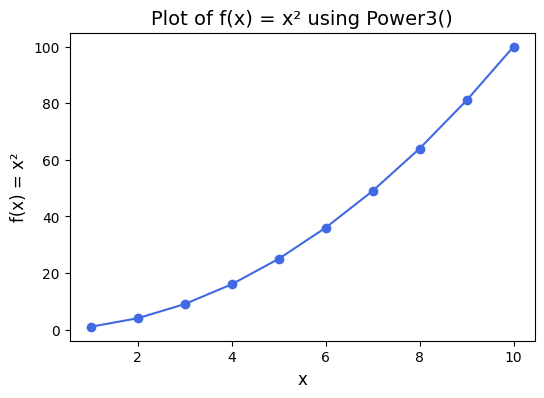

In [114]:
import matplotlib.pyplot as plt
import numpy as np

x = range(1,11)
y = [Power3(i,2) for i in x]

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y, marker='o', linestyle='-', color='royalblue')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x) = x²', fontsize=12)
ax.set_title('Plot of f(x) = x² using Power3()', fontsize=14)

plt.show()

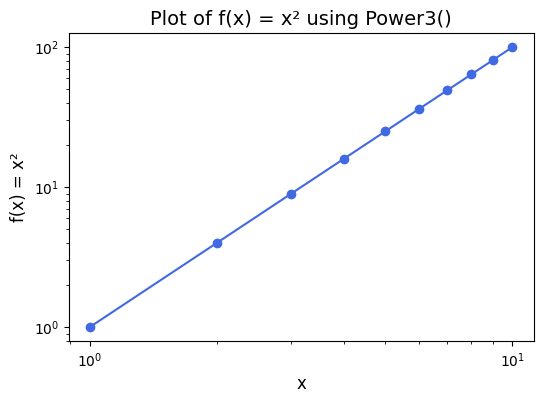

In [116]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(x, y, marker='o', linestyle='-', color='royalblue')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x) = x²', fontsize=12)
ax.set_title('Plot of f(x) = x² using Power3()', fontsize=14)

ax.set_xscale('log')
ax.set_yscale('log')

plt.show()

### (f) Create a function, PlotPower(), that allows you to create a plot of x against x**a for a fixed a and a sequence of values of x. For instance, if you call 
<h3> PlotPower(np.arange(1, 11), 3) 
<h3>then a plot should be created with an x-axis taking on values 1, 2, . . . , 10, and a y-axis taking on values 13, 23, . . . , 103.

In [117]:
def PlotPower(x,a):
    y = x ** a

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(x, y, marker='o', color='royalblue', linewidth=2)

    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel(f'f(x) = x^{a}', fontsize=12)
    ax.set_title(f'Plot of f(x) = x^{a}', fontsize=14)

    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()



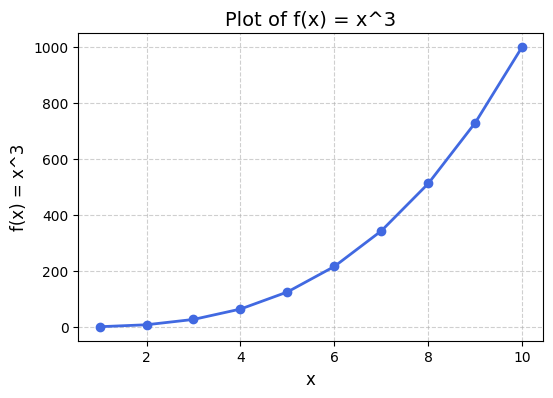

In [118]:
PlotPower(np.arange(1, 11), 3)